<a href="https://colab.research.google.com/github/Anirudh6644/deeplearning/blob/main/11MTCNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import zipfile
import os

zip_file_path = "/content/actors.zip"

extract_dir = "."

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(os.path.abspath(extract_dir))

/content


In [6]:
!pip install mtcnn

In [7]:
import cv2
from mtcnn.mtcnn import MTCNN

In [8]:
detector = MTCNN()

In [13]:
image = cv2.imread("/content/actors/13.jpg")
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


In [14]:
result = detector.detect_faces(image_rgb)

In [15]:
for face in result:
  x, y, w, h = face['box']
  cv2.rectangle(image_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)

(np.float64(-0.5), np.float64(213.5), np.float64(316.5), np.float64(-0.5))

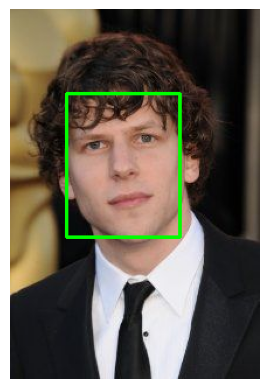

In [16]:
plt.imshow(image_rgb)
plt.axis('off')

Found 1 face(s).


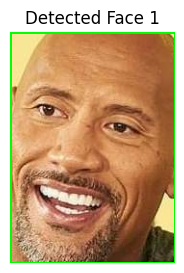

In [ ]:
if result:
    print(f"Found {len(result)} face(s).")
    for i, face in enumerate(result):
        x, y, w, h = face['box']
        cropped_face = image_rgb[y:y+h, x:x+w]

        plt.figure(figsize=(3, 3))
        plt.imshow(cropped_face)
        plt.title(f'Detected Face {i+1}')
        plt.axis('off')
        plt.show()
else:
    print("No faces detected in the image.")